In [8]:
import sys
sys.path.append('..')

import copy
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import importlib.util
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, confusion_matrix, ConfusionMatrixDisplay

from src.dataset import create_train_val_datasets
from config import TRAIN_SIZE, MAX_K, SPLIT_SEED, MAX_SAMPLES_TRAIN, MAX_SAMPLES_VAL, medium_dataset_path, huge_dataset_path, SPLIT_STRATEGY, SEED_TRAIN, SEED_VAL
from src.density_aux import density_auxiliary_loss, unpack_model_output

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device : {device}") 

learning_strategy = "mse"
run_name = Path("runs/run_20260623_171817")
run_path = "../" / run_name / "checkpoints"
model_structure_path = run_path / "model_structure.py"
ckpt_path = run_path / "best_checkpoint.pth"
dataset_path = Path("/sps/l2it/tdonze/gb-dataset-gen/data/synthetic_dataset/dataset_500K_2.0e-23_1.0e-22_filtering_True_10_100_difficulty_1/dataset.hdf5")

Using device : cuda


In [3]:
spec = importlib.util.spec_from_file_location(
    "dynamic_model", model_structure_path
)
dynamic_model_module = importlib.util.module_from_spec(spec)
sys.modules["dynamic_model"] = dynamic_model_module
spec.loader.exec_module(dynamic_model_module)

CardinalityEstimator = getattr(
    dynamic_model_module, "CardinalityEstimator"
)

In [5]:
model = CardinalityEstimator(learning_strategy, max_K=MAX_K, input_channels=4, predict_density=True).to(device)
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

CardinalityEstimator(
  (conv_encoder): Sequential(
    (conv_1): Conv1d(4, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (norm_1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (gelu_1): GELU(approximate='none')
    (conv_2): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (norm_2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (gelu_2): GELU(approximate='none')
    (conv_3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (norm_3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (gelu_3): GELU(approximate='none')
    (conv_4): Conv1d(128, 196, kernel_size=(3,), stride=(1,), padding=(1,))
    (norm_4): BatchNorm1d(196, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (gelu_4): GELU(approximate='none')
  )
  (pos_encoder): PosEnc()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 

In [6]:
def make_dataset_view(base_ds, seed, noise):
    ds = copy.copy(base_ds)

    ds.seed = seed
    ds.noise = noise
    ds.rng = np.random.default_rng(seed)
    
    ds.fixed_mixtures = ds._build_fixed_mixtures()

    return ds

_, base_ds, _ = create_train_val_datasets(
    dataset_path=medium_dataset_path,
    train_size=0.0,
    max_K=MAX_K,
    max_samples_val=None,
    noise_val=True,
    deterministic_val=True,
    split_seed=SPLIT_SEED,
    split_strategy=SPLIT_STRATEGY,
    seed_train=SEED_TRAIN,
    seed_val=SEED_VAL,
    return_params=True
)

[06/24/26 11:15:46] INFO     Loading waveforms from                                                                
                             /sps/l2it/tdonze/gb-dataset-gen/data/synthetic_dataset/dataset_500K_uniform_SNR_10_100
                             /dataset.hdf5...

                    INFO     Total number of waveforms in the dataset: 500000

                    INFO     Starting to load waveforms in memory...

[06/24/26 11:15:54] INFO     Waveforms loaded with shape (500000, 4, 128)

                    INFO     Loading parameters in memory...

...

                    INFO     SNR-based split built with 90 bins of width 1: 0 train / 500000 val

[06/24/26 11:15:55] INFO     Building fixed mixtures for deterministic sampling...

[06/24/26 11:15:59] INFO     Fixed mixtures built successfully.

                    INFO     Building fixed mixtures for deterministic sampling...

[06/24/26 11:16:04] INFO     Fixed mixtures built successfully.

In [9]:
# seeds = [0, 2026, 45, 1234, 5678, 91011, 121314, 151617, 181920, 212223]
seeds = [121314]

all_results = []

done = False
path = Path("mse_evaluation_results_model_density.csv")


if path.exists():
    print(f"File {path} already exists. Loading existing results.")
    results_df = pd.read_csv(path)
    done = True

if not done :
    for run in range(len(seeds)):
        seed = seeds[run]

        print(f"Copying dataset for run {run + 1}, seed : {seed}")
        val_ds = make_dataset_view(base_ds, seed=seed, noise=True)

        signal_ds = copy.copy(val_ds)
        signal_ds.noise = False
        print(f"Dataset copied for run {run + 1}")

        val_loader = DataLoader(val_ds, batch_size=512, shuffle=False)
        signal_loader = DataLoader(signal_ds, batch_size=512, shuffle=False)

        rows = []
        offset = 0

        with torch.no_grad():
            progress = tqdm(
                zip(val_loader, signal_loader),
                total=len(val_loader),
                desc=f"Run {run + 1}/{len(seeds)}",
                leave=True,
            )

            for (summed_waveform, targets, params), (signal_waveform, signal_targets, signal_params) in progress:
                X = torch.as_tensor(summed_waveform, dtype=torch.float32, device=device)
                X_signal = torch.as_tensor(signal_waveform, dtype=torch.float32, device=device)

                targets = torch.as_tensor(targets, dtype=torch.long, device=device)
                signal_targets = torch.as_tensor(signal_targets, dtype=torch.long, device=device)

                assert torch.equal(targets, signal_targets)

                logits, pred_density = unpack_model_output(model(X))

                if learning_strategy == "mse":
                    y = targets.float().unsqueeze(1) / MAX_K # shape : (batch_size, 1)
                    out = torch.sigmoid(logits) # shape : (batch_size, 1)

                    pred_score = out.squeeze(1) * MAX_K # shape : (batch_size,)
                    pred = torch.round(pred_score).long().clamp(1, MAX_K) # shape : (batch_size,)

                    loss_per_sample = F.mse_loss(out, y, reduction="none").squeeze(1) # shape : (batch_size,)
                elif learning_strategy == "ordinal":
                    thresholds = torch.arange(1, MAX_K, device=device) # shape3 : (max_K - 1,)
                    y = (targets.unsqueeze(1) > thresholds.unsqueeze(0)).float() # shape : (batch_size, max_K - 1)

                    probs = torch.sigmoid(logits)

                    pred = 1 + (probs > 0.5).sum(dim=1)
                    pred = pred.clamp(1, MAX_K)

                    pred_score = 1.0 + probs.sum(dim=1)

                    loss_per_sample = F.binary_cross_entropy_with_logits(
                        logits,
                        y,
                        reduction="none",
                    ).mean(dim=1) 
                elif learning_strategy == "cross_entropy":
                    y = targets - 1

                    probs = F.softmax(logits, dim=1)
                    class_values = torch.arange(1, MAX_K + 1, device=device).float()

                    pred = logits.argmax(dim=1) + 1
                    pred_score = (probs * class_values.unsqueeze(0)).sum(dim=1)

                    loss_per_sample = F.cross_entropy(logits, y, reduction="none")
                else:
                    raise ValueError(f"Unknown learning strategy : {learning_strategy}")
                
                processed_logits = out.squeeze() if learning_strategy == "mse" else probs # shape : (batch_size,) for mse, (batch_size, max_K - 1) for ordinal, (batch_size, max_K) for cross_entropy
                snr = torch.as_tensor(params["snr"], dtype=torch.float32, device=device)
                source_mask = torch.as_tensor(params["source_mask"], dtype=torch.bool, device=device)

                snr_masked = torch.where(source_mask, snr, torch.zeros_like(snr))
                snr_mix = torch.sqrt((snr_masked ** 2).sum(dim=1))
                max_snr = snr_masked.max(dim=1).values
                mean_snr = snr_masked.sum(dim=1) / source_mask.sum(dim=1).clamp(min=1)

                # n_visible_5 = ((snr > 5) & source_mask).sum(dim=1)
                # n_visible_10 = ((snr > 10) & source_mask).sum(dim=1)
                # n_visible_20 = ((snr > 20) & source_mask).sum(dim=1)

                energy_noisy = (X ** 2).sum(dim=(1, 2))
                energy_signal = (X_signal ** 2).sum(dim=(1, 2))

                batch_size = targets.shape[0]

                source_mask_cpu = source_mask.detach().cpu()
                optional_param_tensors = {
                    key: torch.as_tensor(params[key]).detach().cpu()
                    for key in [
                        "f0",
                        "freq_bin_start",
                        "freq_bin_stop",
                        "freq_bin_peak",
                        "freq_support_width",
                    ]
                    if key in params
                }

                for i in range(batch_size):
                    mask_i = source_mask_cpu[i]
                    valid_snr = snr[i][source_mask[i]].detach().cpu().numpy()

                    row = {
                        "run": run,
                        "seed": seed,
                        "idx": offset + i,

                        "true_K": int(targets[i].item()),
                        "pred_K": int(pred[i].item()),
                        "pred_score": float(pred_score[i].item()),

                        "correct": bool(pred[i].item() == targets[i].item()),
                        "error_K": int(pred[i].item() - targets[i].item()),
                        "abs_error_K": int(abs(pred[i].item() - targets[i].item())),

                        "processed_logits": processed_logits[i].item() if learning_strategy == "mse" else processed_logits[i].cpu().numpy().tolist(), # shape : () for mse, (max_K - 1,) for ordinal, (max_K,) for cross_entropy
                        "loss": float(loss_per_sample[i].item()),

                        "snr_values": valid_snr.tolist(),
                        "snr_mix": float(snr_mix[i].item()),
                        "max_snr": float(max_snr[i].item()),
                        "mean_snr": float(mean_snr[i].item()),

                        # "n_visible_5": int(n_visible_5[i].item()), # correspond to the number of sources with SNR > 5
                        # "n_visible_10": int(n_visible_10[i].item()), # correspond to the number of sources with SNR > 10
                        # "n_visible_20": int(n_visible_20[i].item()), # correspond to the number of sources with SNR > 20

                        "energy_noisy": float(energy_noisy[i].item()),
                        "energy_signal": float(energy_signal[i].item()),
                    }

                    if "f0" in optional_param_tensors:
                        row["f0_values"] = optional_param_tensors["f0"][i][mask_i].numpy().tolist()
                    for result_key in ["freq_bin_start", "freq_bin_stop", "freq_bin_peak", "freq_support_width"]:
                        if result_key in optional_param_tensors:
                            row[result_key] = optional_param_tensors[result_key][i][mask_i].numpy().astype(int).tolist()

                    rows.append(row)
                offset += batch_size

        df = pd.DataFrame(rows)
        all_results.append(df)
    results_df = pd.concat(all_results, ignore_index=True)
    print(f"Saving results to {path}")
    results_df.to_csv(path, index=False)

Copying dataset for run 1, seed : 121314
Dataset copied for run 1


Run 1/1:   0%|          | 0/977 [00:00<?, ?it/s]

Saving results to mse_evaluation_results_model_density.csv


In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error

LABELS = np.arange(1, MAX_K + 1)

def macro_precision_pm1(y_true, y_pred, labels):
    precisions = []
    for k in labels:
        pred_mask = (y_pred == k)
        
        if np.sum(pred_mask) == 0:
            precisions.append(0.0) 
        else:
            correct_pm1 = np.abs(y_true[pred_mask] - k) <= 1
            precisions.append(np.mean(correct_pm1))
            
    return np.mean(precisions) if precisions else 0.0

def compute_metrics(df, target_col="true_K", pred_col="pred_K"):
    y_true = df[target_col].to_numpy()
    y_pred = df[pred_col].to_numpy()

    return pd.Series({
        "n": len(df),
        "acc": accuracy_score(y_true, y_pred),
        "acc_pm1": np.mean(np.abs(y_true - y_pred) <= 1),
        "precision_pm1_macro": macro_precision_pm1(y_true, y_pred, LABELS),
        "macro_f1": f1_score(y_true, y_pred, labels=LABELS, average="macro", zero_division=0),
        "mae": mean_absolute_error(y_true, y_pred),
        "mean_error": np.mean(y_pred - y_true),
    })


metrics_by_run = results_df.groupby("run").apply(compute_metrics)
display(metrics_by_run)

,n,acc,acc_pm1,precision_pm1_macro,macro_f1,mae,mean_error
run,,,,,,,
0,500000.0,0.849582,0.993442,0.993376,0.849047,0.157216,-0.064024


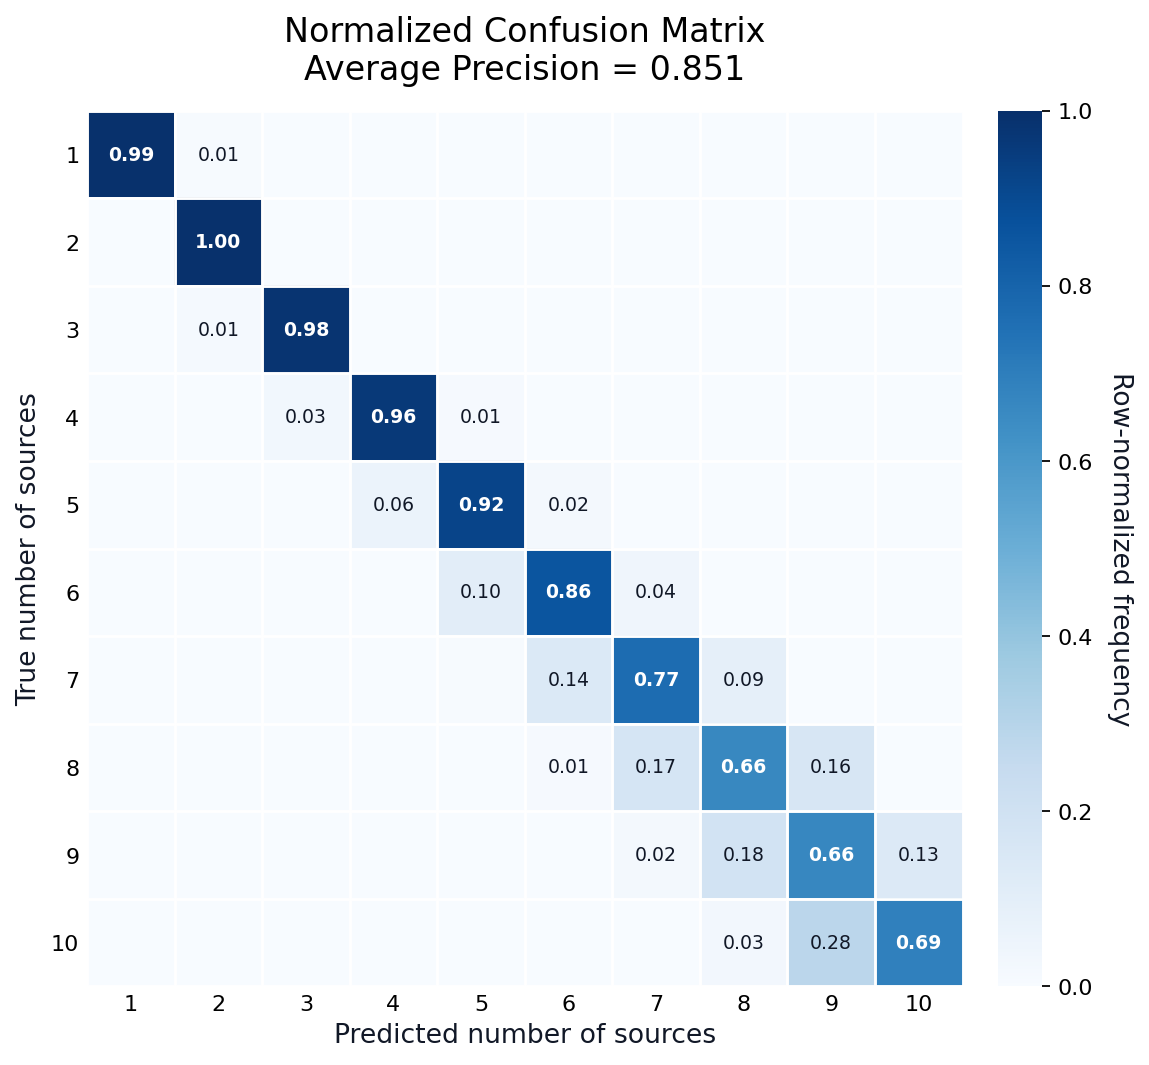

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, f1_score

PRED_COL = "pred_K"
if "results_df" in globals():
    cm_df = results_df.copy()
else:
    results_path = Path("mse_evaluation_results_model_density.csv")
    if not results_path.exists():
        results_path = Path("notebooks") / results_path
    cm_df = pd.read_csv(results_path)

labels = np.arange(1, int(max(cm_df["true_K"].max(), cm_df[PRED_COL].max())) + 1)
cm = confusion_matrix(cm_df["true_K"], cm_df[PRED_COL], labels=labels)
cm_norm = np.divide(
    cm,
    cm.sum(axis=1, keepdims=True),
    out=np.zeros_like(cm, dtype=float),
    where=cm.sum(axis=1, keepdims=True) != 0,
)
accuracy = np.mean(cm_df["true_K"].to_numpy() == cm_df[PRED_COL].to_numpy())
precision_macro = precision_score(cm_df["true_K"], cm_df[PRED_COL], average="macro", zero_division=0)
precision_weighted = precision_score(cm_df["true_K"], cm_df[PRED_COL], average="weighted", zero_division=0)
f1_macro = f1_score(cm_df["true_K"], cm_df[PRED_COL], average="macro", zero_division=0)
f1_weighted = f1_score(cm_df["true_K"], cm_df[PRED_COL], average="weighted", zero_division=0)


with plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#2F3742",
    "axes.labelcolor": "#111827",
    # "axes.titleweight": "bold",
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
}):
    fig, ax = plt.subplots(figsize=(8.4, 7.2), dpi=160)
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")

    # ax.set_title(f"Normalized Confusion Matrix\nAverage Accuracy = {accuracy:.3f}\nAverage Precision (Macro) = {precision_macro:.3f}\nAverage Precision (Weighted) = {precision_weighted:.3f}\nAverage F1-Score (Macro) = {f1_macro:.3f}\nAverage F1-Score (Weighted) = {f1_weighted:.3f}", pad=14)
    ax.set_title(f"Normalized Confusion Matrix\nAverage Precision = {precision_macro:.3f}", pad=14)
    ax.set_xlabel("Predicted number of sources")
    ax.set_ylabel("True number of sources")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.3)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(axis="both", length=0)

    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            value = cm_norm[i, j]
            if value < 0.005:
                continue
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight="bold" if i == j else "normal",
                color="white" if value > 0.45 else "#111827",
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.035)
    cbar.set_label("Row-normalized frequency", rotation=270, labelpad=18)
    cbar.outline.set_visible(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.subplots_adjust(left=0.12, right=0.88, bottom=0.1, top=0.86)
    plt.show()

Using 450,001/500,000 samples with true_K >= 2; weighted-F1 labels=[2, 3, 4, 5, 6, 7, 8, 9, 10]


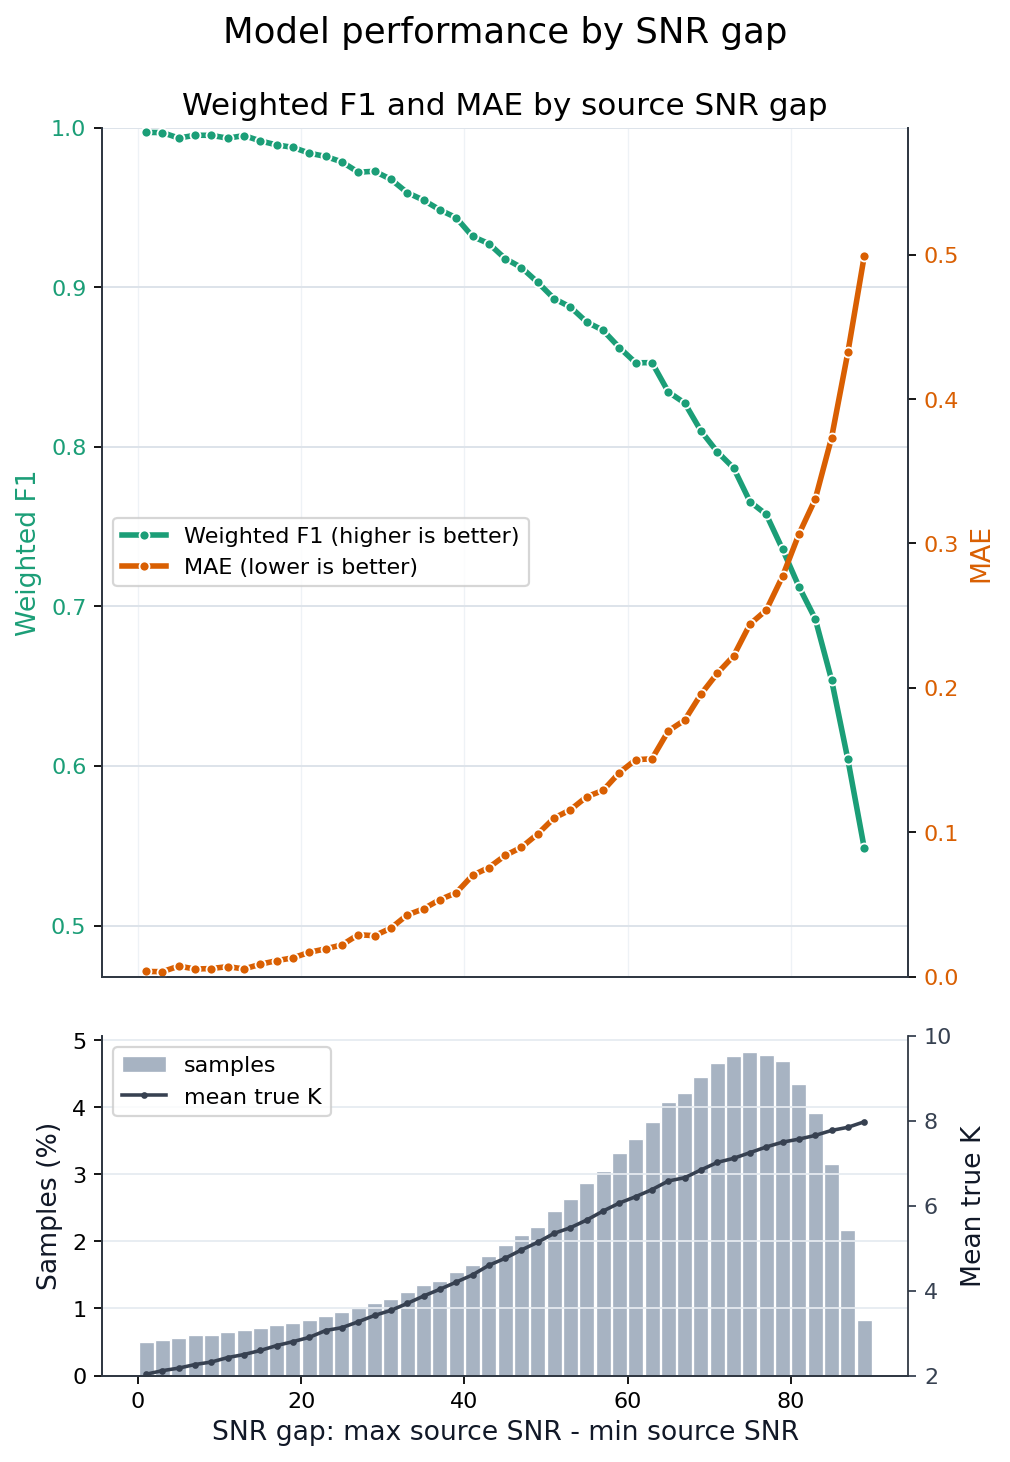

In [12]:
from pathlib import Path
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, mean_absolute_error

PRED_COL = "pred_K"
MIN_K_FOR_GAP_COMPARISON = 2
N_BINS = 45

csv_path = Path("mse_evaluation_results_model_density.csv")
snr_df = pd.read_csv(csv_path)

def parse_snr_values(values):
    if isinstance(values, str):
        values = ast.literal_eval(values)
    return np.asarray(values, dtype=float)

snr_df = snr_df.copy()
snr_arrays = snr_df["snr_values"].map(parse_snr_values)
snr_df["snr_gap"] = snr_arrays.map(
    lambda values: float(values.max() - values.min()) if len(values) else np.nan
)
snr_df["true_K"] = snr_df["true_K"].astype(int)
snr_df[PRED_COL] = snr_df[PRED_COL].astype(int)

max_k = int(globals().get("MAX_K", max(snr_df["true_K"].max(), snr_df[PRED_COL].max())))
f1_labels = np.arange(MIN_K_FOR_GAP_COMPARISON, max_k + 1)

valid = np.isfinite(snr_df["snr_gap"]) & (snr_df["true_K"] >= MIN_K_FOR_GAP_COMPARISON)
analysis_df = snr_df.loc[valid].copy()
if analysis_df.empty:
    raise ValueError("No samples left after SNR-gap and K filtering")

print(
    f"Using {len(analysis_df):,}/{len(snr_df):,} samples with "
    f"true_K >= {MIN_K_FOR_GAP_COMPARISON}; weighted-F1 labels={f1_labels.tolist()}"
)

bin_edges = np.linspace(0.0, np.nanmax(analysis_df["snr_gap"]), N_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_widths = np.diff(bin_edges)

rows = []
for idx, (left, right) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
    if idx == len(bin_edges) - 2:
        mask = (analysis_df["snr_gap"] >= left) & (analysis_df["snr_gap"] <= right)
    else:
        mask = (analysis_df["snr_gap"] >= left) & (analysis_df["snr_gap"] < right)

    bin_df = analysis_df.loc[mask]
    n = int(len(bin_df))
    if n == 0:
        rows.append({
            "center": bin_centers[idx],
            "left": left,
            "right": right,
            "n": n,
            "sample_pct": 0.0,
            "mean_K": np.nan,
            "weighted_f1": np.nan,
            "mae": np.nan,
        })
        continue

    y_true_bin = bin_df["true_K"].to_numpy()
    y_pred_bin = bin_df[PRED_COL].to_numpy()
    rows.append({
        "center": bin_centers[idx],
        "left": left,
        "right": right,
        "n": n,
        "sample_pct": 100 * n / len(analysis_df),
        "mean_K": float(np.mean(y_true_bin)),
        "weighted_f1": f1_score(
            y_true_bin,
            y_pred_bin,
            labels=f1_labels,
            average="weighted",
            zero_division=0,
        ),
        "mae": mean_absolute_error(y_true_bin, y_pred_bin),
    })

metric_by_gap = pd.DataFrame(rows)
hist_frequency = metric_by_gap["sample_pct"].to_numpy()

with plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#2F3742",
    "axes.labelcolor": "#111827",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
}):
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(6, 10),
        dpi=160,
        sharex=True,
        gridspec_kw={"height_ratios": [2.5, 1.0], "hspace": 0.1},
    )

    ax_curve = axes[0]
    ax_hist = axes[1]

    # Tracé du F1 Score (Axe gauche)
    color_f1 = "#1B9E77"
    line_f1 = ax_curve.plot(
        metric_by_gap["center"],
        metric_by_gap["weighted_f1"],
        color=color_f1,
        linewidth=2.5,
        marker="o",
        markersize=4.5,
        markeredgecolor="white",
        markeredgewidth=0.8,
        label="Weighted F1 (higher is better)"
    )
    ax_curve.set_ylabel("Weighted F1", color=color_f1)
    ax_curve.tick_params(axis="y", labelcolor=color_f1)
    ax_curve.grid(axis="y", color="#DDE3EA", linewidth=0.9)
    ax_curve.grid(axis="x", color="#EEF2F6", linewidth=0.6)
    ax_curve.tick_params(axis="x", labelbottom=False, length=0)
    
    # Ajustement de l'axe y gauche
    f1_values = metric_by_gap["weighted_f1"].to_numpy(dtype=float)
    if np.isfinite(f1_values).any():
        y_min = np.nanmin(f1_values)
        y_max = np.nanmax(f1_values)
        pad = max((y_max - y_min) * 0.18, 0.015)
        ax_curve.set_ylim(max(0.0, y_min - pad), min(1.0, y_max + pad))

    # Tracé de la MAE (Axe droit)
    ax_mae = ax_curve.twinx()
    color_mae = "#D95F02"
    line_mae = ax_mae.plot(
        metric_by_gap["center"],
        metric_by_gap["mae"],
        color=color_mae,
        linewidth=2.5,
        marker="o",
        markersize=4.5,
        markeredgecolor="white",
        markeredgewidth=0.8,
        label="MAE (lower is better)"
    )
    ax_mae.set_ylabel("MAE", color=color_mae)
    ax_mae.tick_params(axis="y", labelcolor=color_mae)

    # Ajustement de l'axe y droit
    mae_values = metric_by_gap["mae"].to_numpy(dtype=float)
    if np.isfinite(mae_values).any():
        y_min = np.nanmin(mae_values)
        y_max = np.nanmax(mae_values)
        pad = max((y_max - y_min) * 0.18, 0.015)
        ax_mae.set_ylim(max(0.0, y_min - pad), y_max + pad)

    ax_curve.set_title("Weighted F1 and MAE by source SNR gap")

    # Regroupement des légendes
    lines = line_f1 + line_mae
    labels = [l.get_label() for l in lines]
    ax_curve.legend(lines, labels, loc="center left")

    # Histogramme en dessous
    bars = ax_hist.bar(
        bin_centers,
        hist_frequency,
        width=bin_widths * 0.92,
        align="center",
        color="#A7B3C2",
        edgecolor="white",
        linewidth=0.6,
        label="samples",
    )
    ax_hist.set_ylabel("Samples (%)")
    ax_hist.set_xlabel("SNR gap: max source SNR - min source SNR")
    ax_hist.grid(axis="y", color="#E6EBF1", linewidth=0.8)

    ax_k = ax_hist.twinx()
    line_k = ax_k.plot(
        metric_by_gap["center"],
        metric_by_gap["mean_K"],
        color="#374151",
        linewidth=1.6,
        marker=".",
        markersize=4,
        label="mean true K",
    )
    ax_k.set_ylabel("Mean true K")
    ax_k.set_ylim(MIN_K_FOR_GAP_COMPARISON, max_k)
    ax_k.tick_params(axis="y", colors="#374151")
    
    ax_hist.legend([bars, line_k[0]], ["samples", "mean true K"], loc="upper left")

    # Nettoyage des bordures
    ax_curve.spines["top"].set_visible(False)
    ax_mae.spines["top"].set_visible(False)
    ax_hist.spines["top"].set_visible(False)
    ax_hist.spines["right"].set_visible(False)
    ax_k.spines["top"].set_visible(False)

    fig.suptitle(
        "Model performance by SNR gap",
        fontsize=16,
        y=0.95,
    )
    fig.subplots_adjust(left=0.08, right=0.92, bottom=0.1, top=0.88, hspace=0.1)
    plt.show()

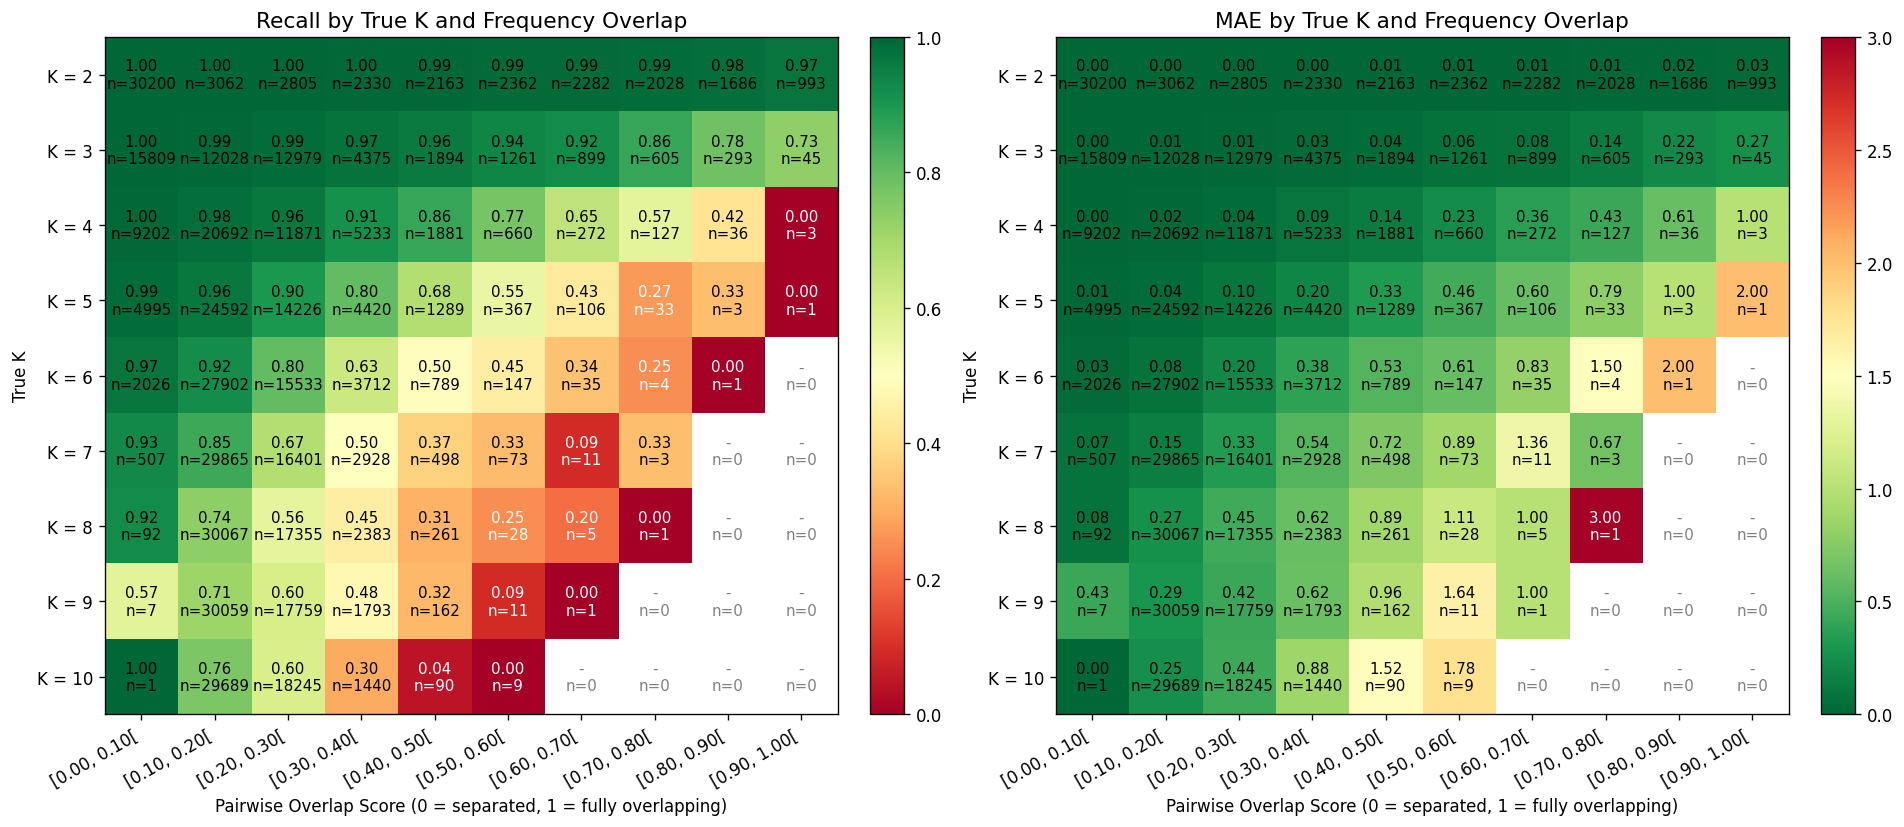

In [13]:
import ast
import itertools
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, mean_absolute_error

# --- CONFIGURATION ---
PRED_COL = "pred_K"
MIN_K_FOR_PLOTS = 2
N_OVERLAP_BINS = 10 # Nombre de colonnes de la matrice

def parse_sequence(values, dtype=int):
    if values is None or (isinstance(values, float) and np.isnan(values)):
        return np.asarray([], dtype=dtype)
    if isinstance(values, str):
        values = ast.literal_eval(values)
    return np.asarray(values, dtype=dtype)

def interval_pairwise_overlap_score(starts, stops):
    starts = np.asarray(starts, dtype=int)
    stops = np.asarray(stops, dtype=int)
    intervals = [(int(start), int(stop)) for start, stop in zip(starts, stops) if start >= 0 and stop > start]
    
    if len(intervals) < 2:
        return 0.0

    scores = []
    for (left_start, left_stop), (right_start, right_stop) in itertools.combinations(intervals, 2):
        inter = max(0, min(left_stop, right_stop) - max(left_start, right_start))
        union = max(left_stop, right_stop) - min(left_start, right_start)
        scores.append(inter / union if union > 0 else 0.0)
    return float(np.mean(scores)) 

# --- CHARGEMENT OU SIMULATION DES DONNÉES ---
csv_path = Path("mse_evaluation_results_model_density.csv")
df = pd.read_csv(csv_path)
df["true_K"] = df["true_K"].astype(int)
df[PRED_COL] = df[PRED_COL].astype(int)

# Calcul de l'overlap si non présent mais que les intervalles existent
if "overlap_score" not in df.columns and "freq_bin_start" in df.columns and "freq_bin_stop" in df.columns:
    starts_arrays = df["freq_bin_start"].map(lambda x: parse_sequence(x, dtype=int))
    stops_arrays = df["freq_bin_stop"].map(lambda x: parse_sequence(x, dtype=int))
    df["overlap_score"] = [interval_pairwise_overlap_score(s, st) for s, st in zip(starts_arrays, stops_arrays)]


df = df[df["true_K"] >= MIN_K_FOR_PLOTS].dropna(subset=["overlap_score"])

bin_edges = np.linspace(0.0, 1.0, N_OVERLAP_BINS + 1)
bin_labels = [
    f"[{bin_edges[i]:.2f}, {bin_edges[i+1]:.2f}[".replace("[1.00[", "[1.00]")
    for i in range(N_OVERLAP_BINS)
]

k_values = sorted(df["true_K"].unique())

exact_match_matrix = np.full((len(k_values), N_OVERLAP_BINS), np.nan)
mae_matrix = np.full((len(k_values), N_OVERLAP_BINS), np.nan)
count_matrix = np.zeros((len(k_values), N_OVERLAP_BINS), dtype=int)

for i, k in enumerate(k_values):
    for j in range(N_OVERLAP_BINS):
        left, right = bin_edges[j], bin_edges[j + 1]

        if j == N_OVERLAP_BINS - 1:
            mask = (
                (df["true_K"] == k)
                & (df["overlap_score"] >= left)
                & (df["overlap_score"] <= right)
            )
        else:
            mask = (
                (df["true_K"] == k)
                & (df["overlap_score"] >= left)
                & (df["overlap_score"] < right)
            )

        sub_df = df[mask]
        n = len(sub_df)
        count_matrix[i, j] = n

        if n > 0:
            y_true = sub_df["true_K"].to_numpy()
            y_pred = sub_df[PRED_COL].to_numpy()

            exact_match_matrix[i, j] = np.mean(y_pred == y_true)
            mae_matrix[i, j] = mean_absolute_error(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=120)

im1 = axes[0].imshow(
    exact_match_matrix,
    cmap="RdYlGn",
    vmin=0.0,
    vmax=1.0,
    aspect="auto",
)
axes[0].set_title("Recall by True K and Frequency Overlap", fontsize=13)

max_mae = np.nanmax(mae_matrix) if np.isfinite(mae_matrix).any() else 1.0
im2 = axes[1].imshow(
    mae_matrix,
    cmap="RdYlGn_r",
    vmin=0.0,
    vmax=max(max_mae, 1.0),
    aspect="auto",
)
axes[1].set_title("MAE by True K and Frequency Overlap", fontsize=13)

for ax, im, mat, label_type in zip(
    axes,
    [im1, im2],
    [exact_match_matrix, mae_matrix],
    ["Exact match", "MAE"],
):
    ax.set_xticks(np.arange(N_OVERLAP_BINS))
    ax.set_xticklabels(bin_labels, rotation=30, ha="right")
    ax.set_yticks(np.arange(len(k_values)))
    ax.set_yticklabels([f"K = {k}" for k in k_values])
    ax.set_xlabel("Pairwise Overlap Score (0 = separated, 1 = fully overlapping)")
    ax.set_ylabel("True K")

    for i in range(len(k_values)):
        for j in range(N_OVERLAP_BINS):
            n = count_matrix[i, j]
            val = mat[i, j]

            if n > 0:
                text = f"{val:.2f}\nn={n}"
                text_color = (
                    "white"
                    if (label_type == "Exact match" and val < 0.3)
                    or (label_type == "MAE" and val > max_mae * 0.7)
                    else "black"
                )
            else:
                text = "-\nn=0"
                text_color = "gray"

            ax.text(j, i, text, ha="center", va="center", color=text_color, fontsize=9)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

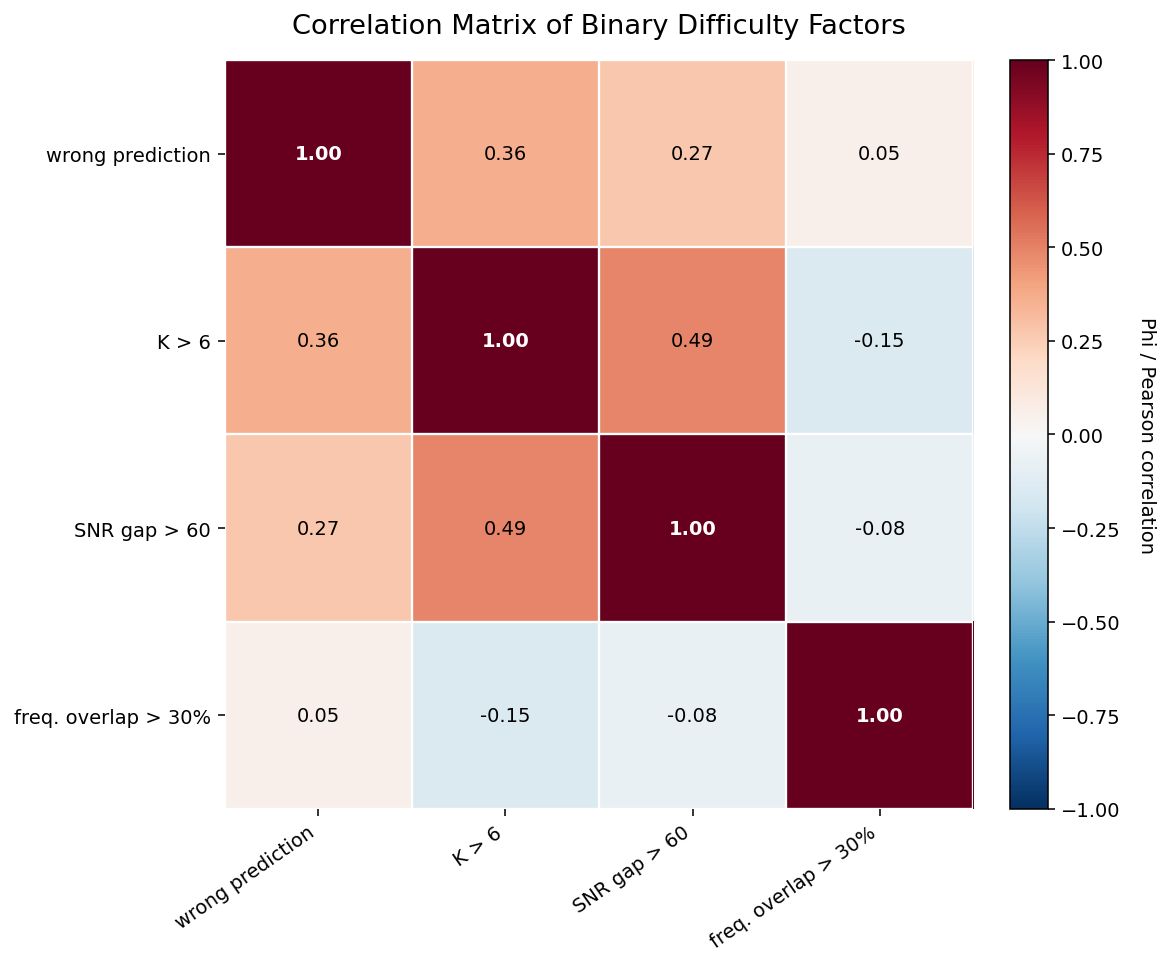

,wrong prediction,K > 6,SNR gap > 60,freq. overlap > 30%
wrong prediction,1.000000,0.361276,0.270254,0.051813
K > 6,0.361276,1.000000,0.486214,-0.148295
SNR gap > 60,0.270254,0.486214,1.000000,-0.076578
freq. overlap > 30%,0.051813,-0.148295,-0.076578,1.000000


In [29]:
import ast
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# Load results CSV
# -----------------------------
csv_candidates = [
    Path("mse_evaluation_results_new.csv"),
    Path("notebooks/mse_evaluation_results_new.csv"),
]

csv_path = next((p for p in csv_candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find mse_evaluation_results_new.csv")

df = pd.read_csv(csv_path).copy()

df["true_K"] = df["true_K"].astype(int)
df["pred_K"] = df["pred_K"].astype(int)


# -----------------------------
# Helpers
# -----------------------------
def parse_sequence(values, dtype=float):
    if values is None or (isinstance(values, float) and np.isnan(values)):
        return np.asarray([], dtype=dtype)
    if isinstance(values, str):
        values = ast.literal_eval(values)
    return np.asarray(values, dtype=dtype)


def compute_snr_gap(values):
    snr = parse_sequence(values, dtype=float)
    if len(snr) == 0:
        return np.nan
    return float(snr.max() - snr.min())


def compute_normalized_dominance(values, true_k):
    snr = parse_sequence(values, dtype=float)
    if len(snr) == 0 or true_k <= 1:
        return np.nan

    snr_power = snr**2
    dominance = float(np.max(snr_power) / np.sum(snr_power))

    min_dominance = 1.0 / true_k
    max_dominance = 1.0
    denom = max_dominance - min_dominance

    if denom <= 0:
        return np.nan

    normalized = (dominance - min_dominance) / denom
    return float(np.clip(normalized, 0.0, 1.0))


def interval_pairwise_overlap_score(starts, stops):
    starts = parse_sequence(starts, dtype=int)
    stops = parse_sequence(stops, dtype=int)

    intervals = [
        (int(start), int(stop))
        for start, stop in zip(starts, stops)
        if start >= 0 and stop > start
    ]

    if len(intervals) < 2:
        return 0.0

    scores = []
    for (a0, a1), (b0, b1) in itertools.combinations(intervals, 2):
        inter = max(0, min(a1, b1) - max(a0, b0))
        union = max(a1, b1) - min(a0, b0)
        scores.append(inter / union if union > 0 else 0.0)

    return float(np.mean(scores))


# -----------------------------
# Compute diagnostic variables
# -----------------------------
df["snr_gap"] = df["snr_values"].map(compute_snr_gap)

df["normalized_dominance"] = [
    compute_normalized_dominance(values, k)
    for values, k in zip(df["snr_values"], df["true_K"])
]

if "overlap_score" not in df.columns:
    if "freq_bin_start" not in df.columns or "freq_bin_stop" not in df.columns:
        raise ValueError("Need freq_bin_start and freq_bin_stop columns to compute frequency overlap")

    df["overlap_score"] = [
        interval_pairwise_overlap_score(starts, stops)
        for starts, stops in zip(df["freq_bin_start"], df["freq_bin_stop"])
    ]


# -----------------------------
# Binary variables
# Thresholds:
# normalized dominance > 30 means > 0.30
# frequency overlap > 30 means > 0.30
# -----------------------------
binary_df = pd.DataFrame({
    "wrong prediction": df["pred_K"] != df["true_K"],
    "K > 6": df["true_K"] > 6,
    "SNR gap > 60": df["snr_gap"] > 60,
    # "norm. dominance > 40%": df["normalized_dominance"] > 0.40,
    "freq. overlap > 30%": df["overlap_score"] > 0.30,
})

binary_df = binary_df.dropna()

corr = binary_df.astype(float).corr(method="pearson")


# -----------------------------
# Plot correlation matrix
# For binary variables, Pearson correlation = phi coefficient
# -----------------------------
fig, ax = plt.subplots(figsize=(8.5, 7), dpi=140)

im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=35, ha="right")
ax.set_yticklabels(corr.index)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        value = corr.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if abs(value) > 0.5 else "black",
            fontsize=10,
            fontweight="bold" if i == j else "normal",
        )

ax.set_title("Correlation Matrix of Binary Difficulty Factors", fontsize=14, pad=14)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Phi / Pearson correlation", rotation=270, labelpad=18)

ax.set_xticks(np.arange(-0.5, len(corr.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(corr.index), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

display(corr)

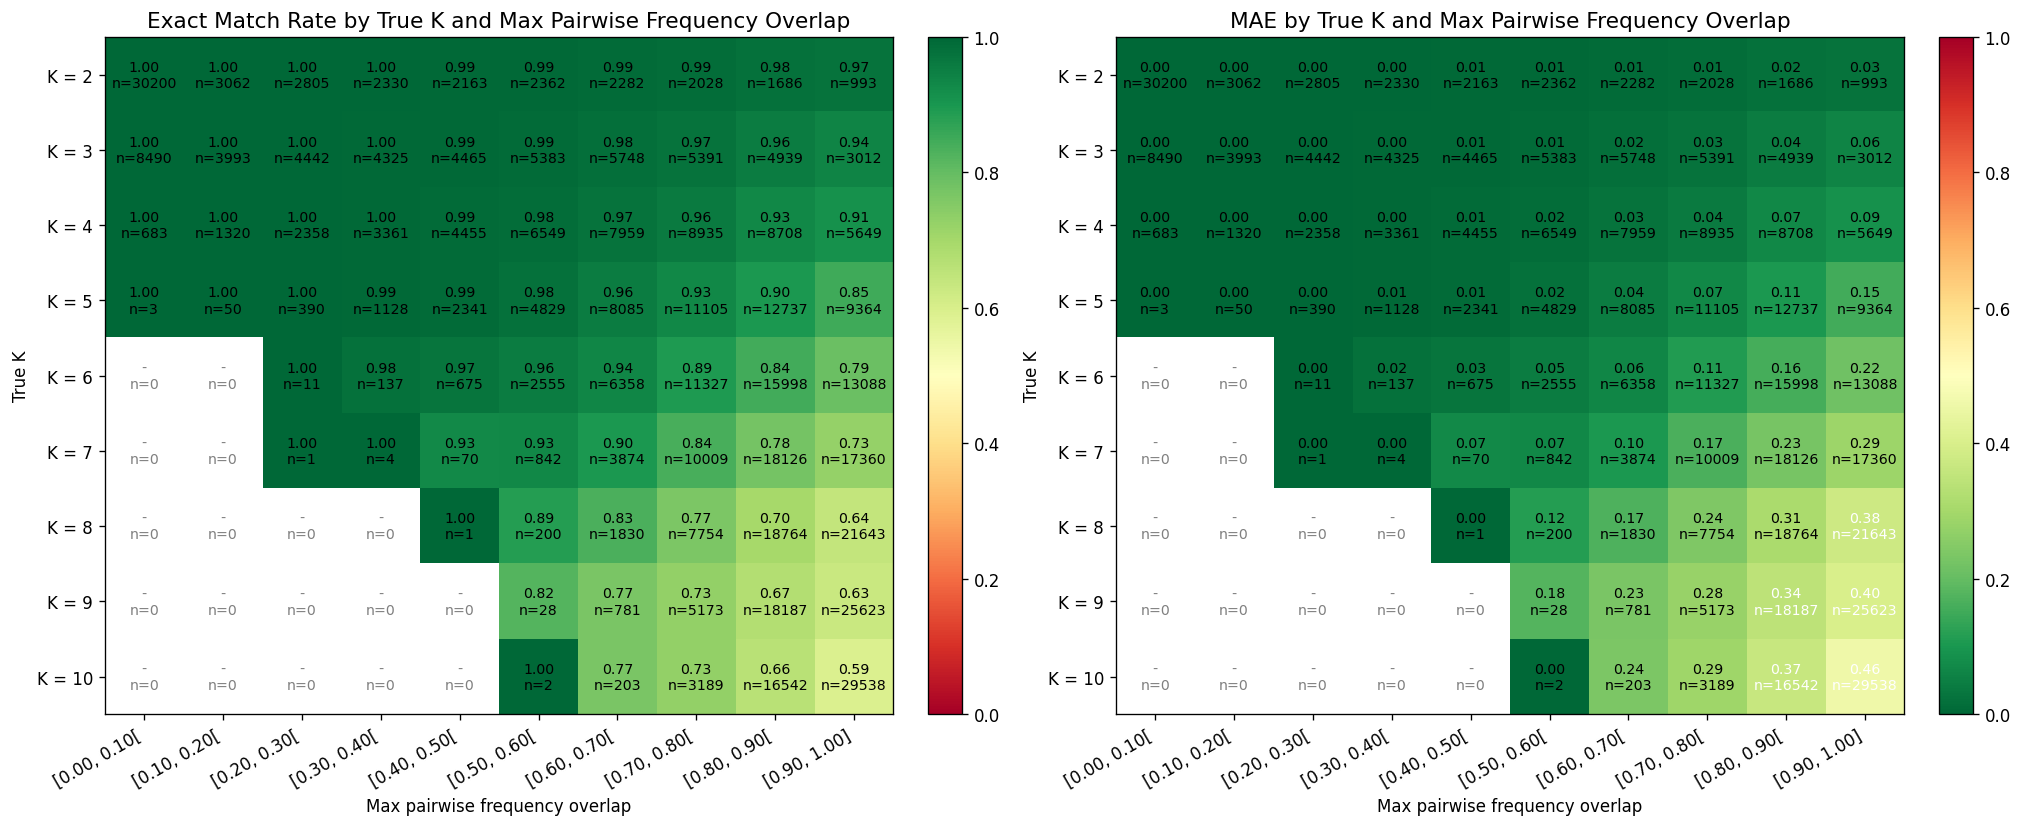

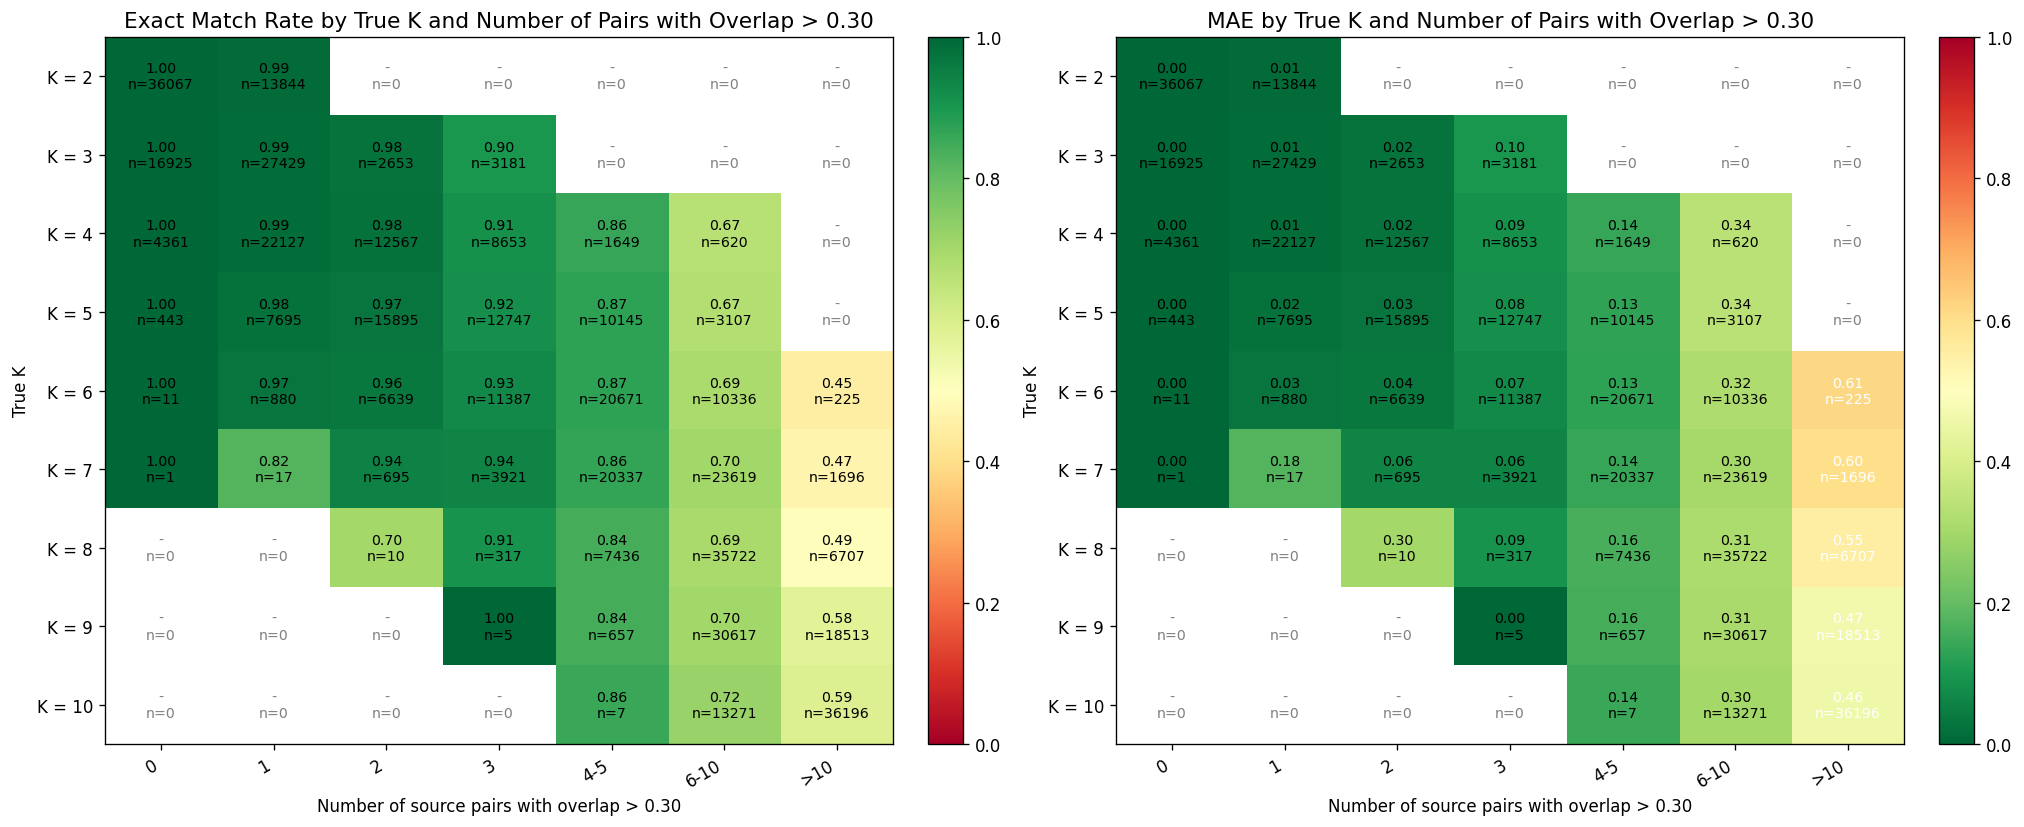

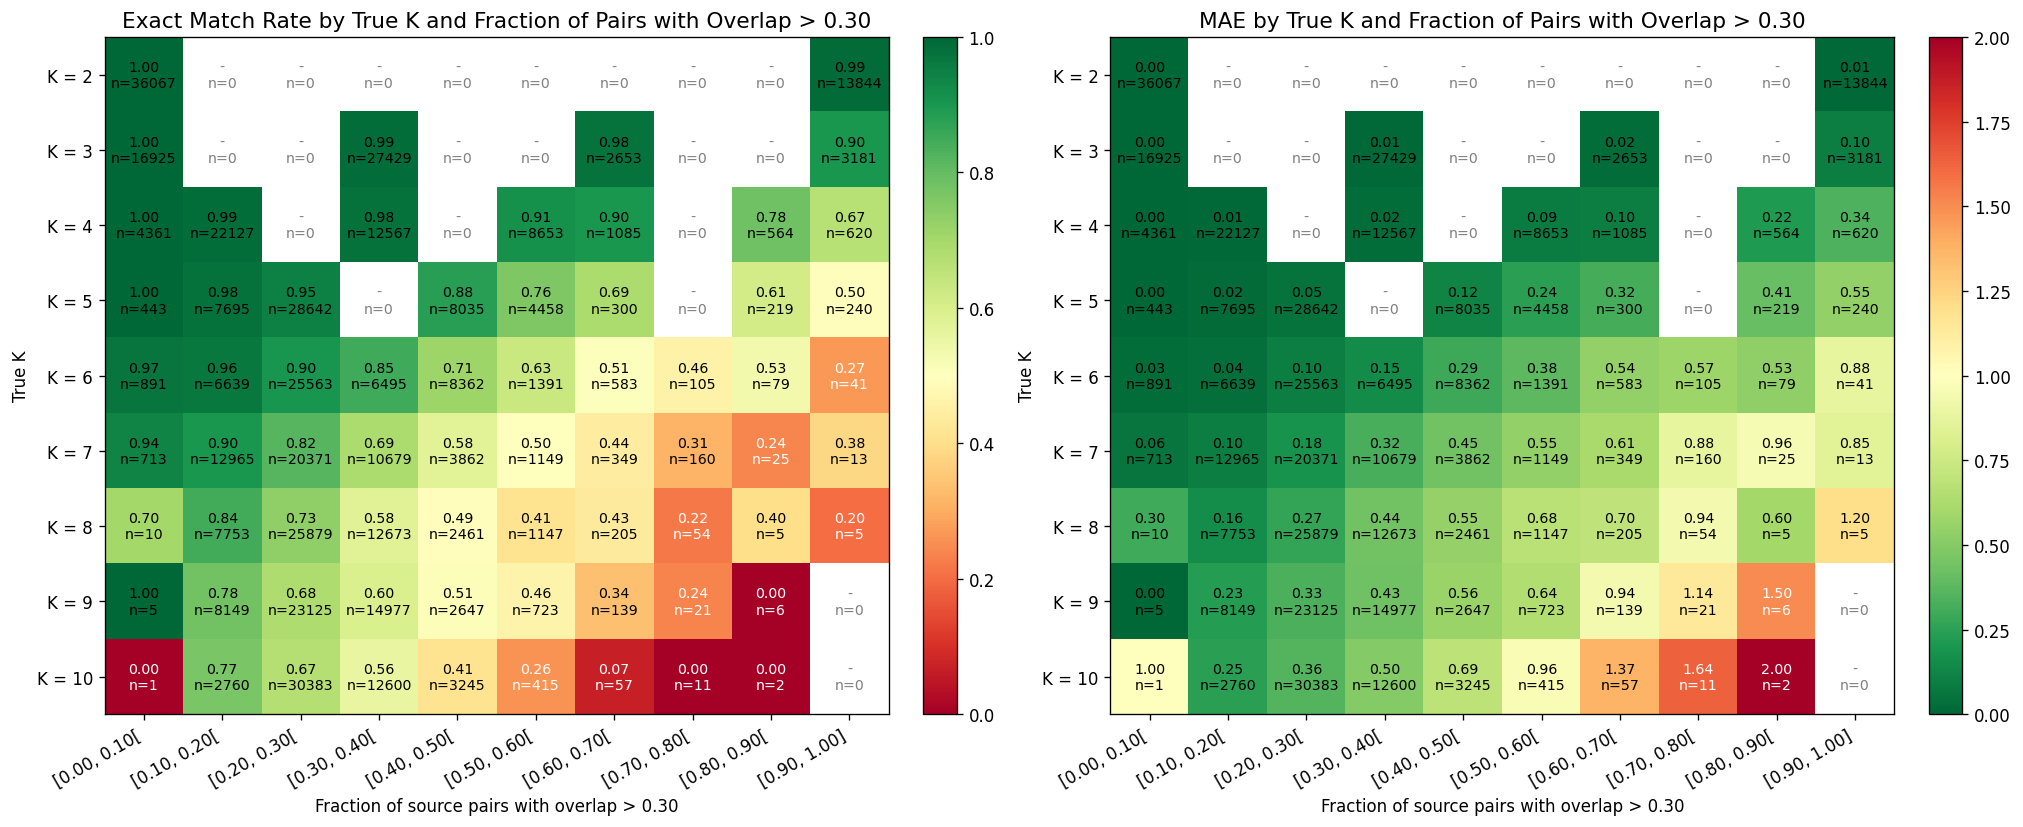

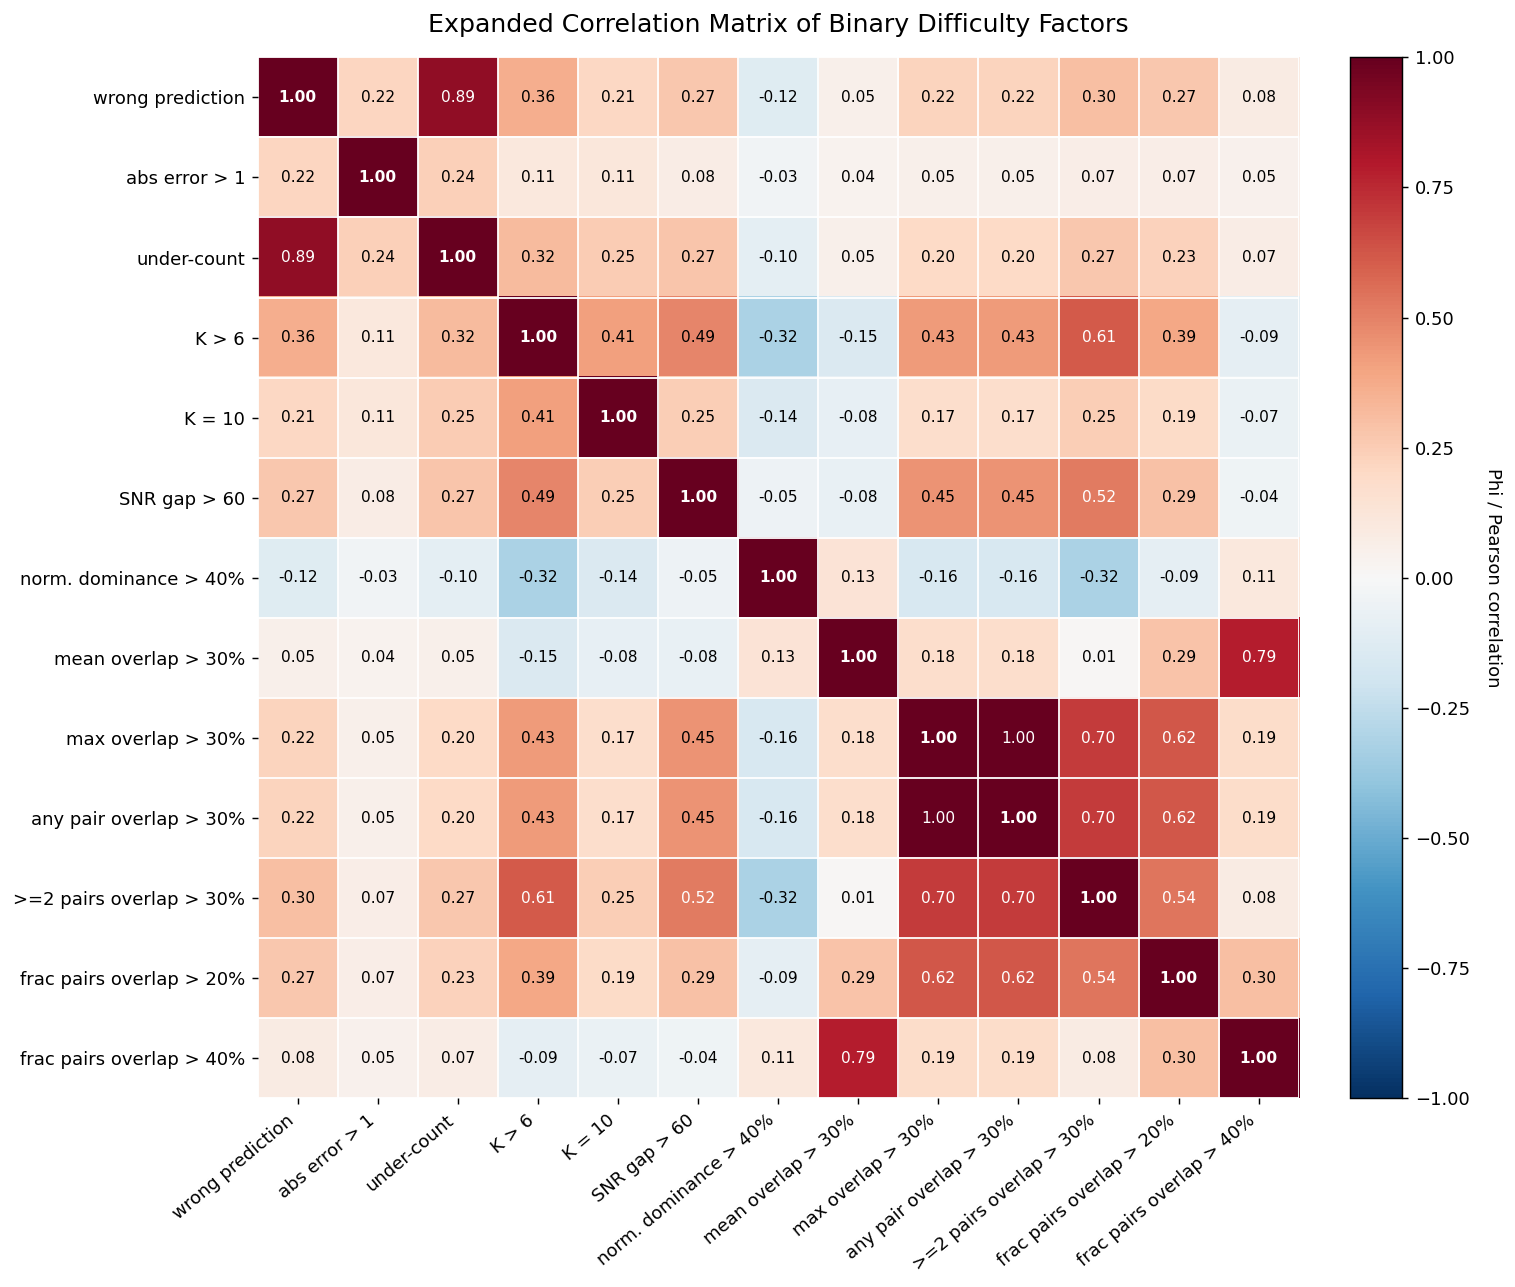

,wrong prediction,abs error > 1,under-count,K > 6,K = 10,SNR gap > 60,norm. dominance > 40%,mean overlap > 30%,max overlap > 30%,any pair overlap > 30%,>=2 pairs overlap > 30%,frac pairs overlap > 20%,frac pairs overlap > 40%
wrong prediction,1.000000,0.218356,0.887167,0.361276,0.206827,0.270254,-0.118127,0.051813,0.220328,0.220328,0.303916,0.265738,0.078787
abs error > 1,0.218356,1.000000,0.241010,0.105242,0.109686,0.077441,-0.032431,0.038808,0.048400,0.048400,0.069085,0.068747,0.046271
under-count,0.887167,0.241010,1.000000,0.316633,0.254132,0.273474,-0.097538,0.053724,0.196424,0.196424,0.269574,0.233495,0.074230
K > 6,0.361276,0.105242,0.316633,1.000000,0.406291,0.486214,-0.317877,-0.148295,0.427617,0.427617,0.611033,0.389280,-0.090631
K = 10,0.206827,0.109686,0.254132,0.406291,1.000000,0.245571,-0.141770,-0.079178,0.173741,0.173741,0.248320,0.188044,-0.065879
SNR gap > 60,0.270254,0.077441,0.273474,0.486214,0.245571,1.000000,-0.051372,-0.076578,0.449654,0.449654,0.516016,0.291874,-0.044764
norm. dominance > 40%,-0.118127,-0.032431,-0.097538,-0.317877,-0.141770,-0.051372,1.000000,0.134770,-0.160074,-0.160074,-0.315672,-0.092240,0.107338
mean overlap > 30%,0.051813,0.038808,0.053724,-0.148295,-0.079178,-0.076578,0.134770,1.000000,0.178684,0.178684,0.011542,0.288508,0.786879
max overlap > 30%,0.220328,0.048400,0.196424,0.427617,0.173741,0.449654,-0.160074,0.178684,1.000000,1.000000,0.699667,0.619052,0.186466
any pair overlap > 30%,0.220328,0.048400,0.196424,0.427617,0.173741,0.449654,-0.160074,0.178684,1.000000,1.000000,0.699667,0.619052,0.186466


In [30]:
import ast
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error


# -----------------------------
# Config
# -----------------------------
PRED_COL = "pred_K"
MIN_K_FOR_PLOTS = 2

PAIR_OVERLAP_THRESHOLD = 0.30

N_MAX_OVERLAP_BINS = 10
N_FRACTION_BINS = 10

# For n_pairs_overlap_gt_0_3, discrete bins are more readable than linspace bins.
N_PAIR_COUNT_BINS = [-0.5, 0.5, 1.5, 2.5, 3.5, 5.5, 10.5, np.inf]
N_PAIR_COUNT_LABELS = ["0", "1", "2", "3", "4-5", "6-10", ">10"]


# -----------------------------
# Load CSV
# -----------------------------
csv_candidates = [
    Path("mse_evaluation_results_new.csv"),
    Path("notebooks/mse_evaluation_results_new.csv"),
]

csv_path = next((p for p in csv_candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find mse_evaluation_results_new.csv")

df = pd.read_csv(csv_path).copy()
df["true_K"] = df["true_K"].astype(int)
df[PRED_COL] = df[PRED_COL].astype(int)


# -----------------------------
# Helpers
# -----------------------------
def parse_sequence(values, dtype=int):
    if values is None or (isinstance(values, float) and np.isnan(values)):
        return np.asarray([], dtype=dtype)
    if isinstance(values, str):
        values = ast.literal_eval(values)
    return np.asarray(values, dtype=dtype)


def pairwise_interval_overlaps(starts, stops):
    starts = parse_sequence(starts, dtype=int)
    stops = parse_sequence(stops, dtype=int)

    intervals = [
        (int(start), int(stop))
        for start, stop in zip(starts, stops)
        if start >= 0 and stop > start
    ]

    if len(intervals) < 2:
        return np.asarray([], dtype=float)

    scores = []
    for (a0, a1), (b0, b1) in itertools.combinations(intervals, 2):
        inter = max(0, min(a1, b1) - max(a0, b0))
        union = max(a1, b1) - min(a0, b0)
        scores.append(inter / union if union > 0 else 0.0)

    return np.asarray(scores, dtype=float)


def compute_overlap_metrics(starts, stops, threshold=0.30):
    overlaps = pairwise_interval_overlaps(starts, stops)

    if len(overlaps) == 0:
        return pd.Series({
            "mean_pairwise_overlap": 0.0,
            "max_pairwise_overlap": 0.0,
            "n_pairs_overlap_gt_0_3": 0,
            "fraction_pairs_overlap_gt_0_3": 0.0,
        })

    return pd.Series({
        "mean_pairwise_overlap": float(np.mean(overlaps)),
        "max_pairwise_overlap": float(np.max(overlaps)),
        "n_pairs_overlap_gt_0_3": int(np.sum(overlaps > threshold)),
        "fraction_pairs_overlap_gt_0_3": float(np.mean(overlaps > threshold)),
    })


def compute_snr_gap(values):
    snr = parse_sequence(values, dtype=float)
    if len(snr) == 0:
        return np.nan
    return float(snr.max() - snr.min())


def compute_normalized_dominance(values, true_k):
    snr = parse_sequence(values, dtype=float)
    if len(snr) == 0 or true_k <= 1:
        return np.nan

    power = snr**2
    dominance = float(np.max(power) / np.sum(power))

    min_dominance = 1.0 / true_k
    denom = 1.0 - min_dominance

    if denom <= 0:
        return np.nan

    return float(np.clip((dominance - min_dominance) / denom, 0.0, 1.0))


def plot_metric_heatmap_pair(df, metric_col, bin_edges, bin_labels, xlabel, title_suffix):
    plot_df = df[df["true_K"] >= MIN_K_FOR_PLOTS].dropna(subset=[metric_col]).copy()
    k_values = sorted(plot_df["true_K"].unique())

    n_bins = len(bin_labels)

    exact_match_matrix = np.full((len(k_values), n_bins), np.nan)
    mae_matrix = np.full((len(k_values), n_bins), np.nan)
    count_matrix = np.zeros((len(k_values), n_bins), dtype=int)

    for i, k in enumerate(k_values):
        for j in range(n_bins):
            left, right = bin_edges[j], bin_edges[j + 1]

            if np.isinf(right):
                mask = (plot_df["true_K"] == k) & (plot_df[metric_col] > left)
            elif j == n_bins - 1:
                mask = (
                    (plot_df["true_K"] == k)
                    & (plot_df[metric_col] >= left)
                    & (plot_df[metric_col] <= right)
                )
            else:
                mask = (
                    (plot_df["true_K"] == k)
                    & (plot_df[metric_col] >= left)
                    & (plot_df[metric_col] < right)
                )

            sub_df = plot_df.loc[mask]
            n = len(sub_df)
            count_matrix[i, j] = n

            if n > 0:
                y_true = sub_df["true_K"].to_numpy()
                y_pred = sub_df[PRED_COL].to_numpy()

                exact_match_matrix[i, j] = np.mean(y_pred == y_true)
                mae_matrix[i, j] = mean_absolute_error(y_true, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(17, 7), dpi=120)

    im1 = axes[0].imshow(
        exact_match_matrix,
        cmap="RdYlGn",
        vmin=0.0,
        vmax=1.0,
        aspect="auto",
    )
    axes[0].set_title(f"Exact Match Rate by True K and {title_suffix}", fontsize=13)

    max_mae = np.nanmax(mae_matrix) if np.isfinite(mae_matrix).any() else 1.0
    im2 = axes[1].imshow(
        mae_matrix,
        cmap="RdYlGn_r",
        vmin=0.0,
        vmax=max(max_mae, 1.0),
        aspect="auto",
    )
    axes[1].set_title(f"MAE by True K and {title_suffix}", fontsize=13)

    for ax, im, mat, label_type in zip(
        axes,
        [im1, im2],
        [exact_match_matrix, mae_matrix],
        ["Exact match", "MAE"],
    ):
        ax.set_xticks(np.arange(n_bins))
        ax.set_xticklabels(bin_labels, rotation=30, ha="right")
        ax.set_yticks(np.arange(len(k_values)))
        ax.set_yticklabels([f"K = {k}" for k in k_values])
        ax.set_xlabel(xlabel)
        ax.set_ylabel("True K")

        for i in range(len(k_values)):
            for j in range(n_bins):
                n = count_matrix[i, j]
                val = mat[i, j]

                if n > 0:
                    text = f"{val:.2f}\nn={n}"
                    text_color = (
                        "white"
                        if (label_type == "Exact match" and val < 0.3)
                        or (label_type == "MAE" and val > max_mae * 0.7)
                        else "black"
                    )
                else:
                    text = "-\nn=0"
                    text_color = "gray"

                ax.text(j, i, text, ha="center", va="center", color=text_color, fontsize=8.5)

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# -----------------------------
# Compute overlap metrics
# -----------------------------
if "freq_bin_start" not in df.columns or "freq_bin_stop" not in df.columns:
    raise ValueError("Need freq_bin_start and freq_bin_stop columns")

overlap_metrics = [
    compute_overlap_metrics(starts, stops, threshold=PAIR_OVERLAP_THRESHOLD)
    for starts, stops in zip(df["freq_bin_start"], df["freq_bin_stop"])
]
overlap_metrics = pd.DataFrame(overlap_metrics)

df = pd.concat([df, overlap_metrics], axis=1)


# -----------------------------
# Heatmap 1: max pairwise overlap
# -----------------------------
edges = np.linspace(0.0, 1.0, N_MAX_OVERLAP_BINS + 1)
labels = [f"[{edges[i]:.2f}, {edges[i+1]:.2f}[" for i in range(N_MAX_OVERLAP_BINS)]
labels[-1] = labels[-1].replace("[", "[").replace("[0.90, 1.00[", "[0.90, 1.00]")

plot_metric_heatmap_pair(
    df=df,
    metric_col="max_pairwise_overlap",
    bin_edges=edges,
    bin_labels=labels,
    xlabel="Max pairwise frequency overlap",
    title_suffix="Max Pairwise Frequency Overlap",
)


# -----------------------------
# Heatmap 2: number of overlapping pairs > 0.30
# -----------------------------
plot_metric_heatmap_pair(
    df=df,
    metric_col="n_pairs_overlap_gt_0_3",
    bin_edges=np.asarray(N_PAIR_COUNT_BINS, dtype=float),
    bin_labels=N_PAIR_COUNT_LABELS,
    xlabel=f"Number of source pairs with overlap > {PAIR_OVERLAP_THRESHOLD:.2f}",
    title_suffix=f"Number of Pairs with Overlap > {PAIR_OVERLAP_THRESHOLD:.2f}",
)


# -----------------------------
# Heatmap 3: fraction of overlapping pairs > 0.30
# -----------------------------
edges = np.linspace(0.0, 1.0, N_FRACTION_BINS + 1)
labels = [f"[{edges[i]:.2f}, {edges[i+1]:.2f}[" for i in range(N_FRACTION_BINS)]
labels[-1] = labels[-1].replace("[0.90, 1.00[", "[0.90, 1.00]")

plot_metric_heatmap_pair(
    df=df,
    metric_col="fraction_pairs_overlap_gt_0_3",
    bin_edges=edges,
    bin_labels=labels,
    xlabel=f"Fraction of source pairs with overlap > {PAIR_OVERLAP_THRESHOLD:.2f}",
    title_suffix=f"Fraction of Pairs with Overlap > {PAIR_OVERLAP_THRESHOLD:.2f}",
)

In [4]:
import ast
import itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# -----------------------------
# Config
# -----------------------------
PRED_COL = "pred_K"
MIN_K_FOR_PLOTS = 2
PAIR_OVERLAP_THRESHOLD = 0.30
N_MAX_OVERLAP_BINS = 10

# -----------------------------
# Helpers
# -----------------------------
def parse_sequence(values, dtype=int):
    if values is None or (isinstance(values, float) and np.isnan(values)):
        return np.asarray([], dtype=dtype)
    if isinstance(values, str):
        values = ast.literal_eval(values)
    return np.asarray(values, dtype=dtype)

def pairwise_interval_overlaps(starts, stops):
    starts = parse_sequence(starts, dtype=int)
    stops = parse_sequence(stops, dtype=int)
    intervals = [(int(start), int(stop)) for start, stop in zip(starts, stops) if start >= 0 and stop > start]
    if len(intervals) < 2:
        return np.asarray([], dtype=float)
    scores = []
    for (a0, a1), (b0, b1) in itertools.combinations(intervals, 2):
        inter = max(0, min(a1, b1) - max(a0, b0))
        union = max(a1, b1) - min(a0, b0)
        scores.append(inter / union if union > 0 else 0.0)
    return np.asarray(scores, dtype=float)

def compute_overlap_metrics(starts, stops, threshold=0.30):
    overlaps = pairwise_interval_overlaps(starts, stops)
    if len(overlaps) == 0:
        return pd.Series({"max_pairwise_overlap": 0.0})
    return pd.Series({"max_pairwise_overlap": float(np.max(overlaps))})

def plot_metric_heatmap_pair(df, metric_col, bin_edges, bin_labels, xlabel, title_suffix):
    plot_df = df[df["true_K"] >= MIN_K_FOR_PLOTS].dropna(subset=[metric_col]).copy()
    k_values = sorted(plot_df["true_K"].unique())
    n_bins = len(bin_labels)

    exact_match_matrix = np.full((len(k_values), n_bins), np.nan)
    mae_matrix = np.full((len(k_values), n_bins), np.nan)
    count_matrix = np.zeros((len(k_values), n_bins), dtype=int)

    for i, k in enumerate(k_values):
        for j in range(n_bins):
            left, right = bin_edges[j], bin_edges[j + 1]
            if np.isinf(right):
                mask = (plot_df["true_K"] == k) & (plot_df[metric_col] > left)
            elif j == n_bins - 1:
                mask = ((plot_df["true_K"] == k) & (plot_df[metric_col] >= left) & (plot_df[metric_col] <= right))
            else:
                mask = ((plot_df["true_K"] == k) & (plot_df[metric_col] >= left) & (plot_df[metric_col] < right))

            sub_df = plot_df.loc[mask]
            n = len(sub_df)
            count_matrix[i, j] = n

            if n > 0:
                y_true = sub_df["true_K"].to_numpy()
                y_pred = sub_df[PRED_COL].to_numpy()
                exact_match_matrix[i, j] = np.mean(y_pred == y_true)
                mae_matrix[i, j] = mean_absolute_error(y_true, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(17, 7), dpi=120)

    im1 = axes[0].imshow(exact_match_matrix, cmap="RdYlGn", vmin=0.4, vmax=1.0, aspect="auto")
    axes[0].set_title(f"Recall by True K and {title_suffix}", fontsize=13)

    max_mae = np.nanmax(mae_matrix) if np.isfinite(mae_matrix).any() else 1.0
    im2 = axes[1].imshow(mae_matrix, cmap="RdYlGn_r", vmin=0.0, vmax=0.6, aspect="auto")
    axes[1].set_title(f"MAE by True K and {title_suffix}", fontsize=13)

    for ax, im, mat, label_type in zip(axes, [im1, im2], [exact_match_matrix, mae_matrix], ["Exact match", "MAE"]):
        ax.set_xticks(np.arange(n_bins))
        ax.set_xticklabels(bin_labels, rotation=30, ha="right")
        ax.set_yticks(np.arange(len(k_values)))
        ax.set_yticklabels([f"K = {k}" for k in k_values])
        ax.set_xlabel(xlabel)
        ax.set_ylabel("True K")

        for i in range(len(k_values)):
            for j in range(n_bins):
                n = count_matrix[i, j]
                val = mat[i, j]
                if n > 0:
                    text = f"{val:.2f}\nn={n}"
                    text_color = "white" if (label_type == "Exact match" and val < 0.3) or (label_type == "MAE" and val > max_mae * 0.7) else "black"
                else:
                    text = "-\nn=0"
                    text_color = "gray"
                ax.text(j, i, text, ha="center", va="center", color=text_color, fontsize=8.5)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

In [5]:

# -----------------------------
# Load CSV and Plot
# -----------------------------
csv_candidates = [Path("mse_evaluation_results_new.csv"), Path("notebooks/mse_evaluation_results_new.csv")]
csv_path = next((p for p in csv_candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find mse_evaluation_results_new.csv")

df = pd.read_csv(csv_path).copy()
df["true_K"] = df["true_K"].astype(int)
df[PRED_COL] = df[PRED_COL].astype(int)

overlap_metrics = [
    compute_overlap_metrics(starts, stops, threshold=PAIR_OVERLAP_THRESHOLD)
    for starts, stops in zip(df["freq_bin_start"], df["freq_bin_stop"])
]
df = pd.concat([df, pd.DataFrame(overlap_metrics)], axis=1)

edges = np.linspace(0.0, 1.0, N_MAX_OVERLAP_BINS + 1)
labels = [f"[{edges[i]:.2f}, {edges[i+1]:.2f}[" for i in range(N_MAX_OVERLAP_BINS)]
labels[-1] = labels[-1].replace("[", "[").replace("[0.90, 1.00[", "[0.90, 1.00]")

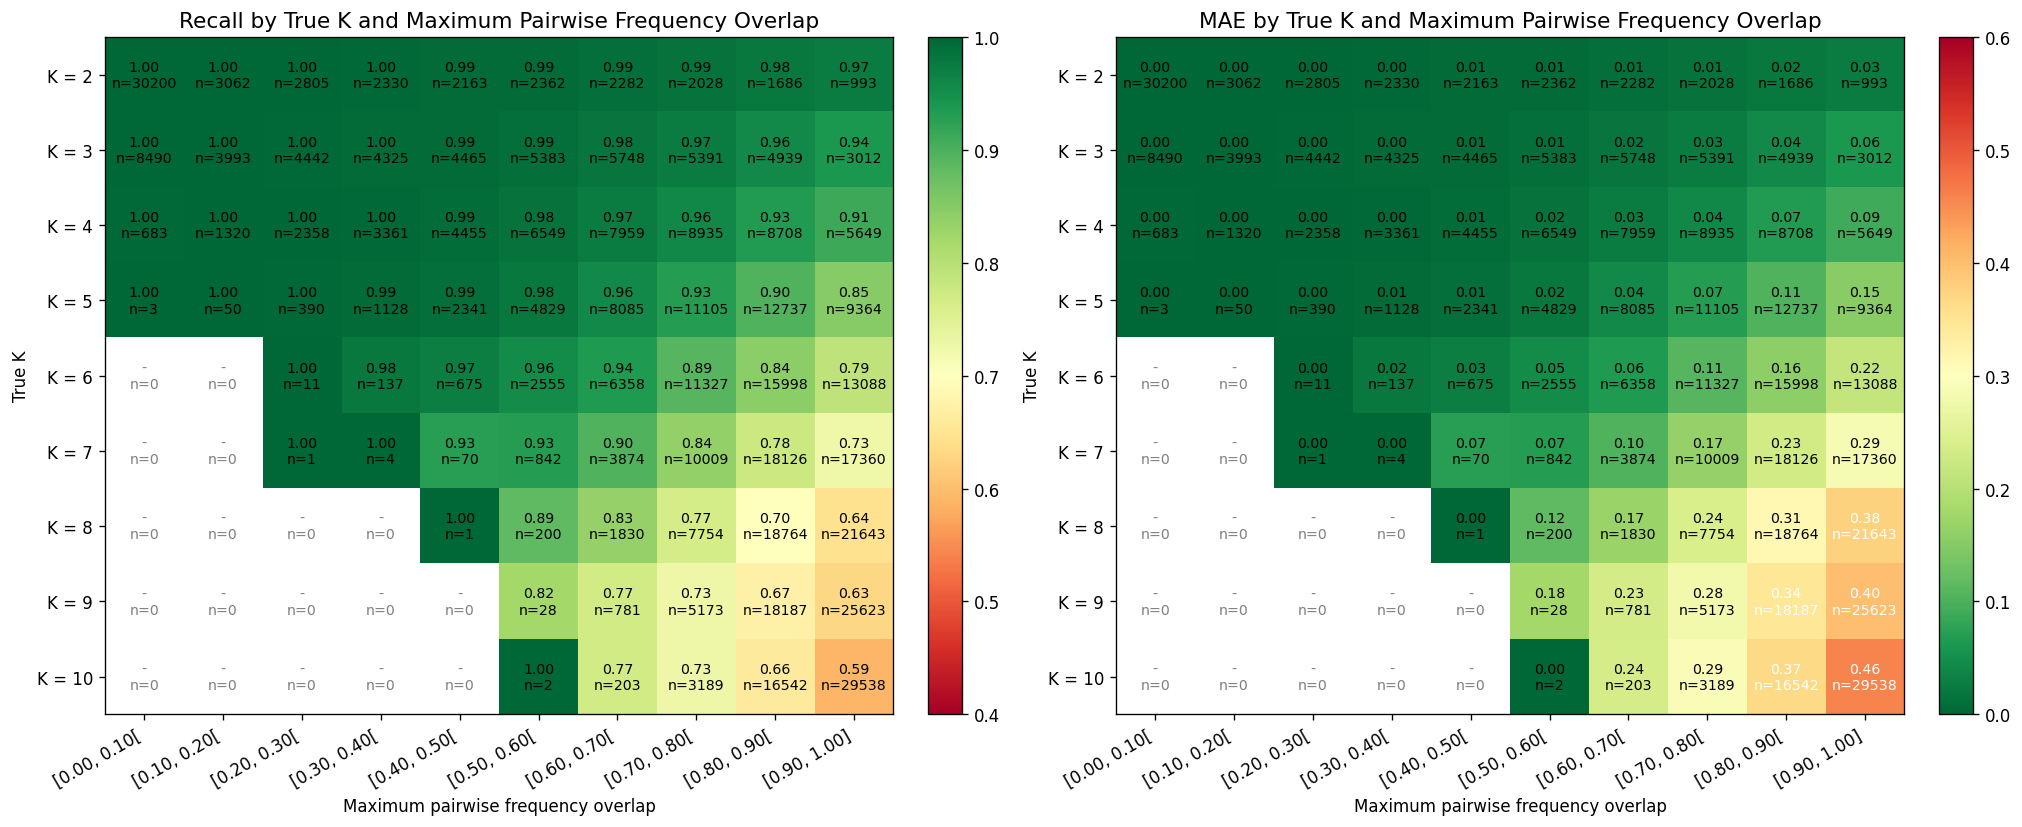

In [6]:
plot_metric_heatmap_pair(
    df=df,
    metric_col="max_pairwise_overlap",
    bin_edges=edges,
    bin_labels=labels,
    xlabel="Maximum pairwise frequency overlap",
    title_suffix="Maximum Pairwise Frequency Overlap",
)

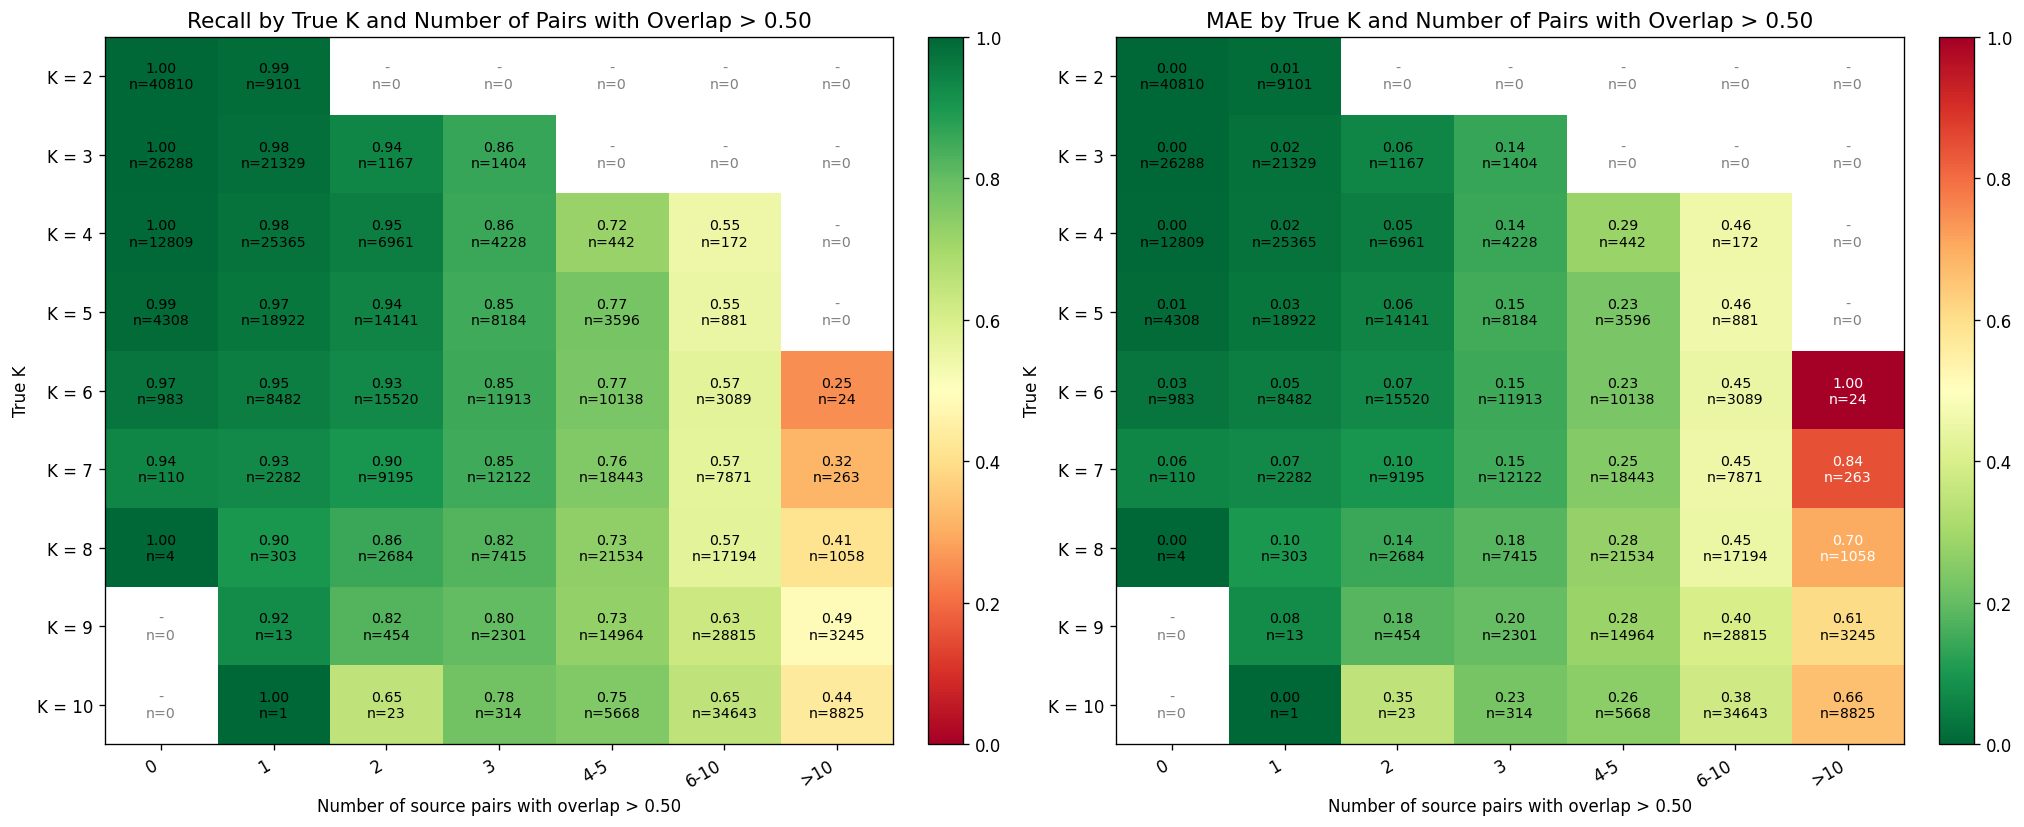

In [1]:
import ast
import itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# -----------------------------
# Config
# -----------------------------
PRED_COL = "pred_K"
MIN_K_FOR_PLOTS = 2
PAIR_OVERLAP_THRESHOLD = 0.50

N_PAIR_COUNT_BINS = [-0.5, 0.5, 1.5, 2.5, 3.5, 5.5, 10.5, np.inf]
N_PAIR_COUNT_LABELS = ["0", "1", "2", "3", "4-5", "6-10", ">10"]

# -----------------------------
# Helpers
# -----------------------------
def parse_sequence(values, dtype=int):
    if values is None or (isinstance(values, float) and np.isnan(values)):
        return np.asarray([], dtype=dtype)
    if isinstance(values, str):
        values = ast.literal_eval(values)
    return np.asarray(values, dtype=dtype)

def pairwise_interval_overlaps(starts, stops):
    starts = parse_sequence(starts, dtype=int)
    stops = parse_sequence(stops, dtype=int)
    intervals = [(int(start), int(stop)) for start, stop in zip(starts, stops) if start >= 0 and stop > start]
    if len(intervals) < 2:
        return np.asarray([], dtype=float)
    scores = []
    for (a0, a1), (b0, b1) in itertools.combinations(intervals, 2):
        inter = max(0, min(a1, b1) - max(a0, b0))
        union = max(a1, b1) - min(a0, b0)
        scores.append(inter / union if union > 0 else 0.0)
    return np.asarray(scores, dtype=float)

def compute_overlap_metrics(starts, stops, threshold=0.50):
    overlaps = pairwise_interval_overlaps(starts, stops)
    if len(overlaps) == 0:
        return pd.Series({"n_pairs_overlap_gt_0_5": 0})
    return pd.Series({"n_pairs_overlap_gt_0_5": int(np.sum(overlaps > threshold))})

def plot_metric_heatmap_pair(df, metric_col, bin_edges, bin_labels, xlabel, title_suffix):
    plot_df = df[df["true_K"] >= MIN_K_FOR_PLOTS].dropna(subset=[metric_col]).copy()
    k_values = sorted(plot_df["true_K"].unique())
    n_bins = len(bin_labels)

    exact_match_matrix = np.full((len(k_values), n_bins), np.nan)
    mae_matrix = np.full((len(k_values), n_bins), np.nan)
    count_matrix = np.zeros((len(k_values), n_bins), dtype=int)

    for i, k in enumerate(k_values):
        for j in range(n_bins):
            left, right = bin_edges[j], bin_edges[j + 1]
            if np.isinf(right):
                mask = (plot_df["true_K"] == k) & (plot_df[metric_col] > left)
            elif j == n_bins - 1:
                mask = ((plot_df["true_K"] == k) & (plot_df[metric_col] >= left) & (plot_df[metric_col] <= right))
            else:
                mask = ((plot_df["true_K"] == k) & (plot_df[metric_col] >= left) & (plot_df[metric_col] < right))

            sub_df = plot_df.loc[mask]
            n = len(sub_df)
            count_matrix[i, j] = n

            if n > 0:
                y_true = sub_df["true_K"].to_numpy()
                y_pred = sub_df[PRED_COL].to_numpy()
                exact_match_matrix[i, j] = np.mean(y_pred == y_true)
                mae_matrix[i, j] = mean_absolute_error(y_true, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(17, 7), dpi=120)

    im1 = axes[0].imshow(exact_match_matrix, cmap="RdYlGn", vmin=0.0, vmax=1.0, aspect="auto")
    axes[0].set_title(f"Recall by True K and {title_suffix}", fontsize=13)

    max_mae = np.nanmax(mae_matrix) if np.isfinite(mae_matrix).any() else 1.0
    im2 = axes[1].imshow(mae_matrix, cmap="RdYlGn_r", vmin=0.0, vmax=max(max_mae, 1.0), aspect="auto")
    axes[1].set_title(f"MAE by True K and {title_suffix}", fontsize=13)

    for ax, im, mat, label_type in zip(axes, [im1, im2], [exact_match_matrix, mae_matrix], ["Recall", "MAE"]):
        ax.set_xticks(np.arange(n_bins))
        ax.set_xticklabels(bin_labels, rotation=30, ha="right")
        ax.set_yticks(np.arange(len(k_values)))
        ax.set_yticklabels([f"K = {k}" for k in k_values])
        ax.set_xlabel(xlabel)
        ax.set_ylabel("True K")

        for i in range(len(k_values)):
            for j in range(n_bins):
                n = count_matrix[i, j]
                val = mat[i, j]
                if n > 0:
                    text = f"{val:.2f}\nn={n}"
                    text_color = "white" if (label_type == "Exact match" and val < 0.5) or (label_type == "MAE" and val > max_mae * 0.7) else "black"
                else:
                    text = "-\nn=0"
                    text_color = "gray"
                ax.text(j, i, text, ha="center", va="center", color=text_color, fontsize=8.5)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

# -----------------------------
# Load CSV and Plot
# -----------------------------
csv_candidates = [Path("mse_evaluation_results_new.csv"), Path("notebooks/mse_evaluation_results_new.csv")]
csv_path = next((p for p in csv_candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find mse_evaluation_results_new.csv")

df = pd.read_csv(csv_path).copy()
df["true_K"] = df["true_K"].astype(int)
df[PRED_COL] = df[PRED_COL].astype(int)

overlap_metrics = [
    compute_overlap_metrics(starts, stops, threshold=PAIR_OVERLAP_THRESHOLD)
    for starts, stops in zip(df["freq_bin_start"], df["freq_bin_stop"])
]
df = pd.concat([df, pd.DataFrame(overlap_metrics)], axis=1)

plot_metric_heatmap_pair(
    df=df,
    metric_col="n_pairs_overlap_gt_0_5",
    bin_edges=np.asarray(N_PAIR_COUNT_BINS, dtype=float),
    bin_labels=N_PAIR_COUNT_LABELS,
    xlabel=f"Number of source pairs with overlap > {PAIR_OVERLAP_THRESHOLD:.2f}",
    title_suffix=f"Number of Pairs with Overlap > {PAIR_OVERLAP_THRESHOLD:.2f}",
)